# Homework 1: Information Retrieval 2026
<div class="warning" style='padding:0.1em; background-color:#adf7a6; color:#000000'>

<p style='margin-top:1em; text-align:center'>
<p style='margin-left:1em;'>
</span>
</div>

## Submission instructions
1.	Students will form teams of 3 students and submit a single solution for the team. Please register your team on the Moodle course page. The same score for the assignment will be given to each member of the team.
2.	Upload your solution as a **ZIP file** to the Moodle course website. The file should archive the provided **Python Jupyter notebook** (including outputs).
    - Name the archived file "ID1_ID2_ID3.ipynb", where ID1, ID2 and ID3 are the IDs of each team member, respectively.
3. Write your code only in the marked sections (`### YOUR CODE HERE`). **Do not remove the code of other sections**. Do not use any imports unless specifically instructed.
   - You can import any basic Python library, including libraries for visualization, working with DataFrame and Math computations (that is, you can use any of the following libraries: `plotly`, `pandas`, `scipy`, `numpy`, `matplotlib` , `seaborn`).
4. Answer any theoretical questions in the given notebook in the relevant cells (📝**QUESTION X**: `### YOUR ANSWER HERE`).
    - **Switch these cells to markdown mode!**
    - **Write your answers in English.**

    
### Notes
1. The goal of this homework is to test your understanding of the IR concepts presented in the lectures.
2. You should ask questions regarding the assignment in the Q&A forum on the Moodle course website.
3. The length of the empty gaps (where you should write your code) is a recommendation and writing longer code will not be considered a mistake. We do not expect you to use the programming tricks and hacks we used to make the code shorter. Having said that, we do encourage you to write good code and keep that in mind - **extreme** cases may be downgraded.  
We also encourage to use informative variable names - it is easier for us to check and for you to understand. 
4. Please use Python 3.10 for programming.
5. Make sure you have all the packages and functions used in the import section. Most of the packages are native to the Anaconda Python distribution.

**Happy coding!**
<div class="warning" style='padding:0.1em; background-color:#adf7a6; color:#000000'>

<p style='margin-top:1em; text-align:center'>
<p style='margin-left:1em;'>
</span>
</div>

# Corpus


The corpus used in this assignment is the **FiQA-2018** dataset, part of the [BEIR](https://github.com/beir-cellar/beir) benchmark for information retrieval evaluation. It consists of approximately 57,600 financial opinion documents drawn from financial forums and question-answering platforms, and is widely used to benchmark IR systems in the financial domain.

We will consider each row in the dataset as a document.

# Imports

In [14]:
import numpy as np
import pandas as pd
from collections import Counter
%matplotlib inline
from tqdm import tqdm
from IPython.display import Image
from IPython.core.display import HTML 
import time
import os
from nltk.tokenize import word_tokenize 
from nltk.stem import WordNetLemmatizer
import nltk
from string import punctuation, ascii_lowercase
from nltk.corpus import stopwords
import seaborn as sb
import matplotlib.pyplot as plt
import sys
import json

nltk.download("stopwords")
nltk.download('wordnet')
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\inked\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\inked\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\inked\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\inked\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [15]:
tic = time.perf_counter() #Start timer

# Config

In [16]:
cwd = os.getcwd()
BOW_PATH = os.path.join(cwd, "bow.csv") # The Bag-of-word model will be saved to this path.
N_ROWS = 1_000_000  # You can override this variable in the relevant places in your code. Setting N_ROWS to a very big number indicates that all documents are used for building the IR model.
CHUNCK_SIZE = 5000
tqdm_n_iterations = N_ROWS // CHUNCK_SIZE + 1
# The name of the column where each document's text is stored
COLS = ["text"]

# Load the corpus

The **FiQA-2018** dataset is a financial opinion mining and question answering.
After un-zipping the dataset file, three files will be produced (and loaded as DataFrames):
- `Docs` (`corpus.jsonl`): Documents. Each document consists of the document's ID (`doc_id`) and its textual content (`text`). Other fields can be ignored.
- `Queries` (`queries.jsonl`): Queries. Each query record consists of the query's ID (`query_id`) and its full text (`text`).
- `Qrels` (`qrels/test.tsv`): Query relevance judgment data. Each record consists of the query's ID (`query_id`), a candidate document ID (`doc_id`) and its relevance score (`relevance`), which can be considered the \"ground truth\".
    - **Details of the dataset are given at: https://sites.google.com/view/fiqa/home**
    - **You should consider a document labelled as relevant if its relevance score is >= 1.**
    - Pay attention to the type of each column in this dataframe.

In [17]:
DATASET_DIR  = r"./fiqa/fiqa"

In [18]:
# Load Docs 
# corpus.jsonl: {"_id": "...", "title": "...", "text": "..."}
docs_data = []
with open(os.path.join(DATASET_DIR, "corpus.jsonl"), encoding="utf-8") as f:
    for line in f:
        row = json.loads(line)
        title = row.get("title", "").strip()
        body  = row.get("text",  "").strip()
        text  = (title + " " + body).strip() if title else body
        docs_data.append({"doc_id": str(row["_id"]), "text": text})
docs_df = pd.DataFrame(docs_data)[["doc_id", "text"]].iloc[:N_ROWS]

# Load Queries
# queries.jsonl: {"_id": "...", "text": "..."}
queries_data = []
with open(os.path.join(DATASET_DIR, "queries.jsonl"), encoding="utf-8") as f:
    for line in f:
        row = json.loads(line)
        queries_data.append({"query_id": str(row["_id"]), "text": row["text"]})
queries_df = pd.DataFrame(queries_data)[["query_id", "text"]]

# Load Qrels (test split)
# qrels/test.tsv: query-id  corpus-id  score   (tab-separated, with header)
qrels_df = pd.read_csv(
    os.path.join(DATASET_DIR, "qrels", "test.tsv"),
    sep="\t",
    dtype={"query-id": str, "corpus-id": str, "score": int}
).rename(columns={"query-id": "query_id", "corpus-id": "doc_id", "score": "relevance"})

# Keep only queries that appear in the test qrels
queries_df = queries_df[queries_df["query_id"].isin(qrels_df["query_id"])].reset_index(drop=True)

# A) Build a Bag of words /TfIdf model

## 1. Implement the following methods

* `preprocess_sentence`: 
    * Lower case a word.
    * Ignore a word if it belongs to the given stopwords list (`stop_words` variable).
    * Remove characters which are not in a given set of the allowed symbols (`allowed_symbols` variable).
    * Perform lemmatization on each word. Append the processed words to the output sentence (`output_sentence` variable).
    * Discard words with length <= 1.
    
* `update_counts_and_probabilities`: 

    * Update `self.unigram` count (how many times each word appears in the text).
    * Update `self.bigram` count (two consecutive word occurrences).
    * Update the inverted index: a dictionary with words as keys and its values are dictionaries of the form - {'<DocID>' : word_count} .  
    
* `compute_word_document_frequency`:

   * For each word, count the number of documents it appears in.

* `update_inverted_index_with_tf_idf_and_compute_document_norm`:

    * Update the inverted index (which currently holds word counts) with tf-idf weighting. We will compute "tf" by dividing the term's count with the number of words in each document. 
    * Incrementally update the document norm (`self.doc_norms` variable). Pay attention that later we apply the function `np.sqrt` to it to finish the process.

> ⚠ Note: *The result of this code is a bag-of-words model with TF-IDF weighing.*

In [19]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
allowed_symbols = set(l for l in ascii_lowercase)

In [20]:
def preprocess_sentence(sentence) -> list:
    '''
    The function preprocesses a sentence by tokenizing it, removing stop words,
    performing lemmatization, and removing punctuation and non-English words.

    Parameters
    ----------
    sentence : str
        a string representing a sentence
    
    Returns
    -------
    list
        a list of processed words
    '''
    output_sentence = []

    for word in word_tokenize(sentence):
        word = word.lower()
        word = ''.join(ch for ch in word if ch in allowed_symbols)
        if len(word) <= 1:
            continue
        if word in stop_words:
            continue
        word = lemmatizer.lemmatize(word)
        if len(word) <= 1:
            continue
        output_sentence.append(word)

    ### END YOUR CODE
    return output_sentence
    

def split_dataframe(): 
    chunks = list()
    num_chunks = len(docs_df) // CHUNCK_SIZE + 1
    for i in range(num_chunks):
        chunks.append(docs_df[i * CHUNCK_SIZE: (i + 1) * CHUNCK_SIZE])
    return chunks

In [21]:
class TfIdf:
    def __init__(self):
        #unigram_count is a dictionary that maps a word to the number of times it appears in the corpus
        self.unigram_count =  Counter()
        #bigram_count is a dictionary that maps a bigram to the number of times it appears in the corpus
        self.bigram_count = Counter()
        #document_term_frequency is a dictionary that maps a document ID to the number of words in the document
        self.document_term_frequency = Counter()
        #word_document_frequency is a dictionary that maps a word to the number of documents it appears in
        self.word_document_frequency = {}
        #inverted_index is a dictionary that maps a word to a dictionary that maps a document ID to the weight of the word in that document
        self.inverted_index = {}
        #doc_norms is a dictionary that maps a document ID to the norm of the document
        self.doc_norms = {}
        #n_docs is the number of documents in the corpus
        self.n_docs = 0
        #sentence_preprocesser is a function that preprocesses a sentence
        self.sentence_preprocesser = preprocess_sentence
        #bow_path is the path to the bag of words
        self.bow_path = BOW_PATH

    def update_counts_and_probabilities(self, sentence: list, document_id: int) -> None:
        '''
        The function updates the unigram and bigram counts and the inverted index given a sentence and a document ID

        Parameters
        ----------
        sentence : list
            a list of words
        document_id : int
            the ID of the document
        
        Returns
        -------
        None
        '''
        sentence_len = len(sentence)
        self.document_term_frequency[document_id] = sentence_len
        for i, word in enumerate(sentence):
            self.unigram_count[word] += 1
            self.inverted_index.setdefault(word, {})
            self.inverted_index[word][document_id] = self.inverted_index[word].get(document_id, 0) + 1

            if i < sentence_len - 1:
                bigram = (word, sentence[i + 1])
                self.bigram_count[bigram] += 1
        
        
    def fit(self) -> None:
        for chunck in tqdm(split_dataframe(), total=tqdm_n_iterations):
            for sentence in chunck[COLS[0]].values: #sentence is a document (string)
                document_id = self.n_docs
                self.n_docs += 1
                if not isinstance(sentence, str):
                    continue
                sentence = self.sentence_preprocesser(sentence)
                if sentence:
                    self.update_counts_and_probabilities(sentence, document_id)
        self.save_bow() # bow is 'bag of words'
        self.compute_word_document_frequency()
        self.update_inverted_index_with_tf_idf_and_compute_document_norm()
             
    def compute_word_document_frequency(self):
        '''
        This function computes the word document frequency for each word in the inverted index. e.g. if a word appears in 10 documents, the word document frequency is 10.
        '''
        for word in self.inverted_index.keys():
            self.word_document_frequency[word] = len(self.inverted_index[word])
            
    def update_inverted_index_with_tf_idf_and_compute_document_norm(self):
        '''
        This function updates the inverted index with tf-idf weighting and computes the document norm for each document.
        '''
        for word, doc_counts in self.inverted_index.items():
            idf = np.log(self.n_docs / self.word_document_frequency[word]) if self.word_document_frequency[word] else 0.0
            for doc_id, count in doc_counts.items():
                tf = count / self.document_term_frequency[doc_id]
                tf_idf = tf * idf
                doc_counts[doc_id] = tf_idf
                self.doc_norms[doc_id] = self.doc_norms.get(doc_id, 0.0) + (tf_idf ** 2)
        for doc in self.doc_norms.keys():
            self.doc_norms[doc] = np.sqrt(self.doc_norms[doc]) 
            
    def save_bow(self):
        pd.DataFrame([self.inverted_index]).T.to_csv(self.bow_path)


> ⚠ Note: *You can ignore the progress percentage shown during the execution of the cell below. It is only an approximation. When the cell terminates its run successfully, you will see an output number appear to the left of the cell.*

In [22]:
tf_idf = TfIdf()
tf_idf.fit()

  6%|▌         | 12/201 [04:15<1:07:03, 21.29s/it]


### 1.1 Analyze the Bag-of-Words (BOW) model

📝**QUESTION A1: What is the computational complexity of this model, as a function of the relevant factors, including the number of docs in the corpus?**

**Q A1 Answer:**

Using the notation from the complexity chart: \(D\) is the number of documents in the corpus, \(N\) is the average number of words in a document, and \(n\) is the number of unique terms in the corpus.

The BOW/TF-IDF model scans all documents and processes each word once. Since there are \(D\) documents and each document has about \(N\) words, the preprocessing and counting stage takes \(O(D \cdot N)\). The implementation uses hash-based structures such as `Counter`, dictionaries, and an inverted index, so updating term counts is \(O(1)\) on average per word.

After building the counts, the model computes document frequencies and TF-IDF weights by scanning the unique terms and their posting lists. The total number of postings is at most the total number of processed words, so this step is also bounded by \(O(D \cdot N)\). Therefore, the total build complexity is \(O(D \cdot N)\).

The space complexity is \(O(n + D \cdot N + D)\), for the unique terms, inverted index postings, and per-document statistics such as document lengths and norms.

# B) Run Document Retrieval

## 2.1 Implement the following methods

`reduce_query_to_counts`: given a list of words, returns a counter object with words as keys and counts as values.

`rank`: given a query and relevant documents, calculate the similarity (cosine or inner product simialrity) between each document and the query.   
Make sure to transform the query word counts to tf-idf as well. 

`sort_and_retrieve_k_best`: returns the top k documents.

In [23]:
class DocumentRetriever:
    def __init__(self, tf_idf):
        #sentence_preprocesser is a function that preprocesses a sentence
        self.sentence_preprocesser = preprocess_sentence  
        #vocab is a set of all the words in the corpus
        self.vocab = set(tf_idf.unigram_count.keys())
        #n_docs is the number of documents in the corpus
        self.n_docs = tf_idf.n_docs
        #inverted_index is a dictionary that maps a word to a dictionary that maps a document ID to the weight of the word in the document
        self.inverted_index = tf_idf.inverted_index
        #word_document_frequency is a dictionary that maps a word to the number of documents it appears in
        self.word_document_frequency = tf_idf.word_document_frequency
        #doc_norms is a dictionary that maps a document ID to the norm of the document
        self.doc_norms = tf_idf.doc_norms
        
    def rank(self, query: dict, documents: dict, metric: str) -> dict:
        '''
        The function ranks the documents according to the query and the chosen similarity metric

        Parameters
        ----------
        query : dict
            a dictionary of words and their counts in the query
        documents : dict
            a dictionary of documents that contain the query words and their tf-idf weights
        metric : str
            the similarity metric to use. Can be either 'cosine' or 'dot'
        
        Returns
        -------
        dict
            a dictionary of documents and their similarity to the query
        '''
        result = {} # key: DocID , value : float , similarity to query
        query_len = np.sum(np.array(list(query.values())))
        
        # Compute query TF-IDF weights and query norm
        query_norm = 0.0
        query_tfidf = {}
        
        for word, count in query.items():
            if word in self.word_document_frequency:
                tf = count / query_len
                idf = np.log(self.n_docs / self.word_document_frequency[word])
                tf_idf = tf * idf
                query_tfidf[word] = tf_idf
                query_norm += tf_idf ** 2
        
        query_norm = np.sqrt(query_norm)
        
        # Collect all document IDs that contain query words
        all_doc_ids = set()
        for word in query_tfidf.keys():
            if word in documents and documents[word] is not None:
                all_doc_ids.update(documents[word].keys())
        
        # Calculate dot product similarity for each document
        for doc_id in all_doc_ids:
            similarity = 0.0
            for word, query_weight in query_tfidf.items():
                if word in documents and documents[word] is not None:
                    doc_weight = documents[word].get(doc_id, 0.0)
                    similarity += query_weight * doc_weight
            result[doc_id] = similarity
        
        # Apply cosine normalization if needed
        if metric == 'cosine':
            for doc_id in result:
                if self.doc_norms[doc_id] > 0 and query_norm > 0:
                    result[doc_id] = result[doc_id] / (query_norm * self.doc_norms[doc_id])
                else:
                    result[doc_id] = 0.0
        
        return result
        
    
    def sort_and_retrieve_k_best(self, scores: dict, k: int) -> list:
        '''
        This function sorts the documents according to their similarity to the query and returns the k best documents
        '''
        sorted_docs = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        return [doc_id for doc_id, score in sorted_docs[:k]]

    
    def reduce_query_to_counts(self, query: list) -> Counter:
        '''
        This function reduces the query to a dictionary of words and their counts
        '''
        return Counter(query)
        
        
    def get_top_k_documents(self, query: str, metric: str, k=5) -> list:
        query = self.sentence_preprocesser(query)
        query = [word for word in query if word in self.vocab] # filter nan 
        query_bow = self.reduce_query_to_counts(query)
        relavant_documents = {word : self.inverted_index.get(word) for word in query}
        ducuments_with_similarity = self.rank(query_bow, relavant_documents, metric)
        return self.sort_and_retrieve_k_best(ducuments_with_similarity, k)
        
dr = DocumentRetriever(tf_idf)

## 2.2 Evaluate document retrieval

### 2.2.1 R-precision

Implement the evaluation **R-Precision** metric. **R-Precision** measures the precision after $r$ documents have been retrieved by the IR engine, defined as follows:

$$ R\text{-}Precision(q) = \frac{\text{Number of relevant documents among the top-}r\text{ retrieved}}{r} $$

where $r$ is the total number of relevant items for the query $q$.

The R-Precision metric tells us how precise the IR system is when retrieving as many documents as are truly relevant.
You can read about the different IR metrics [here](https://www.shaped.ai/blog/evaluating-recommendation-systems-part-1).

In [24]:
def r_precision(r, retrieved_query_relevant_docs, reference_query_relevant_docs):
    '''
    The function calculates the precision after r documents have been retrieved by the IR engine
    
    Parameters
    ----------
    r : int
        Total number of relevant documents
    retrieved_query_relevant_docs : list
        a list of the retrieved document IDs by the IR engine for a given query 
    reference_query_relevant_docs : list
        a list of the real relevant document IDs for a given query
    
    Returns
    -------
    float
        R-Precision value
    '''
    
    # Get the top r retrieved documents
    top_r_retrieved = retrieved_query_relevant_docs[:r]
    
    # Count how many of the top r retrieved documents are in the reference list
    relevant_count = sum(1 for doc in top_r_retrieved if doc in reference_query_relevant_docs)
    
    # Calculate R-Precision as the ratio of relevant documents in top-r to r
    if r == 0:
        return 0.0
    
    return relevant_count / r

### 2.2.2 Evaluate query performance

Find the **the most relevant document** for each query in the query set according to each similarity metric as follows:
- cosine similarity
- inner product

Print the query, the document's ID and it text (*enable scrolling in the cell's output*).

Note: Pay attention that the indexes that are returned from the function `get_top_k_documents` are the row indexes of the relevant documents and not their IDs.

In [25]:
for i in range(queries_df.shape[0]):
    query_id = queries_df.iloc[i]['query_id']
    query_text = queries_df.iloc[i]['text']
    
    # Get top 1 document for cosine similarity
    top_doc_cosine = dr.get_top_k_documents(query_text, metric='cosine', k=1)
    
    # Get top 1 document for dot product similarity
    top_doc_dot = dr.get_top_k_documents(query_text, metric='dot', k=1)
    
    # Print query information
    print(f"Query {i+1}: {query_text}")
    print(f"Query ID: {query_id}\n")
    
    if top_doc_cosine:
        doc_index = top_doc_cosine[0]
        doc_id = docs_df.iloc[doc_index]['doc_id']
        doc_text = docs_df.iloc[doc_index]['text']
        print(f"Top Document (Cosine Similarity):")
        print(f"  Doc ID: {doc_id}")
        print(f"  Text: {doc_text}\n")
    
    if top_doc_dot:
        doc_index = top_doc_dot[0]
        doc_id = docs_df.iloc[doc_index]['doc_id']
        doc_text = docs_df.iloc[doc_index]['text']
        print(f"Top Document (Dot Product):")
        print(f"  Doc ID: {doc_id}")
        print(f"  Text: {doc_text}\n")
    
    print("-" * 80)

Query 1: Where should I park my rainy-day / emergency fund?
Query ID: 4641

Top Document (Cosine Similarity):
  Doc ID: 376148
  Text: Bond aren't necessarily any safer than the stock market.  Ultimately, there is no such thing as a low risk mutual fund. You want something that will allow you get at your money relatively quickly. In other words, CDs (since you you can pick a definite time period for your money to be tied up), money market account or just a plain old savings account. Basically, you want to match inflation and have easy access to the money.  Any other returns on top of that are gravy, but don't fret too much about it. See also: Where can I park my rainy-day / emergency fund? Savings accounts don’t generate much interest. Where should I park my rainy-day / emergency fund?

Top Document (Dot Product):
  Doc ID: 551764
  Text: Here are some options: Park your money in a bank that works best for you.

--------------------------------------------------------------------------

📝**QUESTION B1: Manually evalute the performance of the retrieval mechanism on several queries picked at random. What similarity metric achieves better results? Why?**

**Q B1 Answer:**

From the sample queries, cosine similarity generally gives better retrieval results than inner product. In several cases, cosine returns a document that is clearly closer to the query topic, while inner product sometimes prefers a longer or more generic document because it accumulates a larger raw score.

This happens because cosine similarity normalizes by document and query length, so it compares the actual direction of the TF-IDF vectors rather than just their magnitude. That makes it more robust for retrieval. In contrast, inner product is biased toward longer documents and higher total term weights, even when the document is not the most relevant one.

### 2.2.3 Evaluate IR performance as a function of the corpus size

Run the document retrieval engine per increasing corpus sizes (slice the corpus to extract a corpus of some size, using the `N_ROWS` variable). Use at least 3 sizes, one of which is the full corpus size (which is the default setting use have previously used).
- Evaluate the IR performance on the entire query set (the query file `queries_df`) using two similarity metrics - cosine similarity and inner product.

In [26]:
top_k_all_queries = pd.DataFrame()

# Keep a copy of the full corpus so we can slice it repeatedly
_docs_df_full = docs_df.copy()
_full_size = len(_docs_df_full)

# Use at least 3 corpus sizes, including the full corpus
_corpus_sizes = [max(1, _full_size // 4), max(1, _full_size // 2), _full_size]
_corpus_sizes = sorted(set(_corpus_sizes))

_results = []

for _size in _corpus_sizes:
    print(f"Building retrieval model on {_size} documents...")
    
    # Slice the corpus to the requested size and rebuild the model
    docs_df = _docs_df_full.iloc[:_size].reset_index(drop=True)
    tqdm_n_iterations = len(docs_df) // CHUNCK_SIZE + 1
    
    _tf_idf = TfIdf()
    _tf_idf.fit()
    _dr = DocumentRetriever(_tf_idf)
    
    for _, _query_row in queries_df.iterrows():
        _query_id = _query_row["query_id"]
        _query_text = _query_row["text"]
        
        for _metric in ["cosine", "dot"]:
            _retrieved = _dr.get_top_k_documents(_query_text, metric=_metric, k=1)
            if _retrieved:
                _doc_index = _retrieved[0]
                _doc_id = docs_df.iloc[_doc_index]["doc_id"]
            else:
                _doc_index = None
                _doc_id = None
            
            _results.append({
                "corpus_size": _size,
                "metric": _metric,
                "query_id": _query_id,
                "query_text": _query_text,
                "retrieved_row_index": _doc_index,
                "retrieved_doc_id": _doc_id,
            })

# Restore the full corpus
docs_df = _docs_df_full

top_k_all_queries = pd.DataFrame(_results)


Building retrieval model on 14409 documents...


  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:30<00:00, 10.05s/it]


Building retrieval model on 28819 documents...


100%|██████████| 6/6 [02:58<00:00, 29.83s/it]


Building retrieval model on 57638 documents...


100%|██████████| 12/12 [05:54<00:00, 29.57s/it]


Evaluate each version of the document retrieval model (per each corpus size) on all the queries in the given query file according to each of the two similarity metrics - cosine similarity and inner product.

For each similarity metric, calculate the average R-Precision metric over all the queries.
  - Store the metrics in a convinient data sctructure to easily plot the results.

In [ ]:
# Save the full docs_df so we can restore it after each iteration
docs_df_full = docs_df.copy()
full_size = len(docs_df_full)

# Choose at least 3 corpus sizes, including the full corpus
corpus_sizes = sorted({max(1, full_size // 4), max(1, full_size // 2), full_size})

precision_cosine_by_size = {}
precision_dot_by_size    = {}

# Precompute relevant document IDs for each query
relevant_docs_by_query = (
    qrels_df[qrels_df["relevance"] >= 1]
    .groupby("query_id")["doc_id"]
    .apply(list)
    .to_dict()
)

def _r_precision(r, retrieved_query_relevant_docs, reference_query_relevant_docs):
    if r == 0:
        return 0.0
    top_r_retrieved = retrieved_query_relevant_docs[:r]
    relevant_count = sum(1 for doc in top_r_retrieved if doc in reference_query_relevant_docs)
    return relevant_count / r

for size in corpus_sizes:
    print(f"\nBuilding model on {size} documents...")
    
    # Slice the corpus and rebuild the model for this corpus size
    docs_df = docs_df_full.iloc[:size].reset_index(drop=True)
    original_tqdm_iterations = tqdm_n_iterations
    tqdm_n_iterations = len(docs_df) // CHUNCK_SIZE + 1
    
    tf_idf = TfIdf()
    tf_idf.fit()
    dr = DocumentRetriever(tf_idf)
    
    cosine_scores = []
    dot_scores = []
    
    for _, query_row in queries_df.iterrows():
        query_id = query_row["query_id"]
        query_text = query_row["text"]
        reference_docs = relevant_docs_by_query.get(query_id, [])
        r = len(reference_docs)
        
        retrieved_cosine = dr.get_top_k_documents(query_text, metric="cosine", k=len(docs_df))
        retrieved_dot = dr.get_top_k_documents(query_text, metric="dot", k=len(docs_df))
        
        retrieved_cosine_doc_ids = [docs_df.iloc[idx]["doc_id"] for idx in retrieved_cosine]
        retrieved_dot_doc_ids = [docs_df.iloc[idx]["doc_id"] for idx in retrieved_dot]
        
        cosine_scores.append(_r_precision(r, retrieved_cosine_doc_ids, reference_docs))
        dot_scores.append(_r_precision(r, retrieved_dot_doc_ids, reference_docs))
    
    precision_cosine_by_size[size] = float(np.mean(cosine_scores)) if cosine_scores else 0.0
    precision_dot_by_size[size] = float(np.mean(dot_scores)) if dot_scores else 0.0
    
    tqdm_n_iterations = original_tqdm_iterations

# Restore full corpus
docs_df = docs_df_full


Building model on 14409 documents...


100%|██████████| 3/3 [01:14<00:00, 24.99s/it]



Building model on 28819 documents...


100%|██████████| 6/6 [02:26<00:00, 24.48s/it]



Building model on 57638 documents...


100%|██████████| 12/12 [05:56<00:00, 29.71s/it]


Visualize the difference between the performance of each document retrieval model (trained on a corpus of a different size) across the two similarity metrics (cosine similarity and inner product).
- Plot the IR performance as a function of the corpus size.
- Plot a line corresponding to each similarity metric (cosine similarity and inner product).
- Give meaningful names to the axes and the plot.
- Make sure to include a corresponding legend.

Organize the dictionaries with the precision results in a single DataFrame (it will be easier to plot a dataFrame using [seaborn](https://seaborn.pydata.org/generated/seaborn.lineplot.html)).

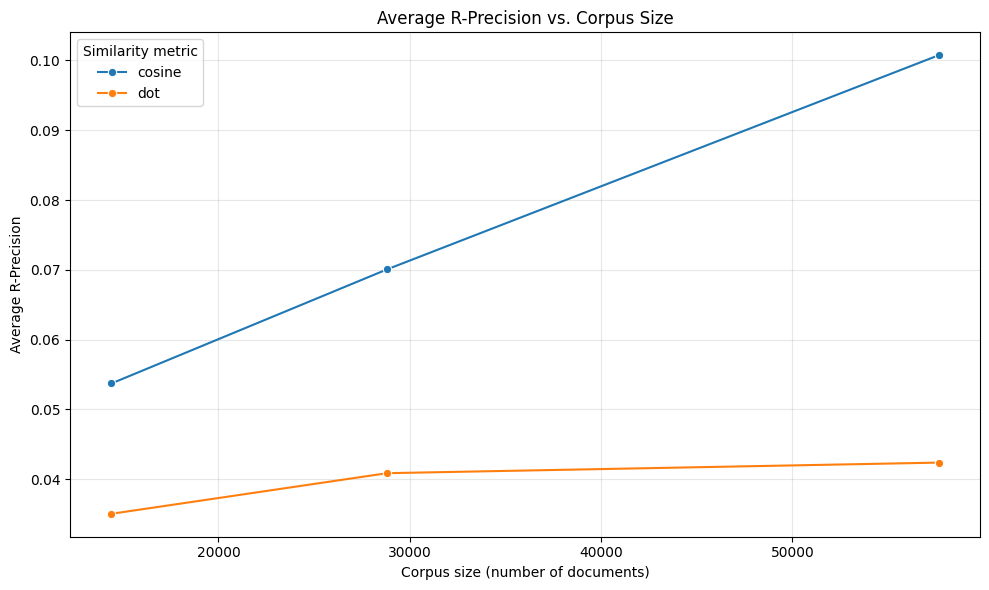

In [92]:
results_df = pd.DataFrame(
    [
        {"corpus_size": size, "metric": "cosine", "precision": precision_cosine_by_size[size]}
        for size in precision_cosine_by_size
    ]
    + [
        {"corpus_size": size, "metric": "dot", "precision": precision_dot_by_size[size]}
        for size in precision_dot_by_size
    ]
)

results_df = results_df.sort_values(["corpus_size", "metric"]).reset_index(drop=True)

plt.figure(figsize=(10, 6))
sb.lineplot(
    data=results_df,
    x="corpus_size",
    y="precision",
    hue="metric",
    marker="o",
)
plt.title("Average R-Precision vs. Corpus Size")
plt.xlabel("Corpus size (number of documents)")
plt.ylabel("Average R-Precision")
plt.legend(title="Similarity metric")
plt.grid(True, alpha=0.3)
plt.tight_layout()

📝**QUESTION B2: Breifly state and explain your conclusions regarding the results above. What can you learn from the relationship between the corpus size and the performance of the IR engine?**

**Q B2 Answer:**




### 2.2.4 Evaluate IR performance as a function of query length

Query length, i.e., the number of tokens remaining after preprocessing, can strongly affect retrieval quality. A very short query (e.g. a single word) is ambiguous; it matches many documents, making it hard for the engine to rank the truly relevant ones highly. A longer query provides more constraints, potentially yielding a higher-precision result.

Group the queries in `queries_df` by their **preprocessed length** into three buckets:
- **Short**: 1–4 tokens after preprocessing
- **Medium**: 5–10 tokens
- **Long**: 11 or more tokens

Use the **full-corpus model** (`dr`) already trained at the beginning of the assignment.

> ⚠ Note: Queries whose preprocessed form is empty (all tokens were stop words or non-alphabetic) should be skipped.

In [93]:
# Preprocess queries: compute token list, token length and assign bucket labels
def _bucket_label(length):
    if length <= 0:
        return None
    if length <= 4:
        return "Short (1-4 tokens)"
    if length <= 10:
        return "Medium (5-10 tokens)"
    return "Long (11+ tokens)"

# Apply preprocessing to each query text (use the existing `preprocess_sentence` function)
queries_df['tokens'] = queries_df['text'].apply(lambda t: preprocess_sentence(t) if isinstance(t, str) else [])
queries_df['token_len'] = queries_df['tokens'].apply(len)
queries_df['bucket'] = queries_df['token_len'].apply(_bucket_label)

# Drop queries that became empty after preprocessing (as instructed)
queries_df_preprocessed = queries_df[queries_df['token_len'] > 0].copy().reset_index(drop=True)

# Quick summary
print('Total queries (original):', len(queries_df))
print('Total queries after preprocessing (non-empty):', len(queries_df_preprocessed))
print(queries_df_preprocessed['bucket'].value_counts(dropna=True).to_dict())

# The variable `queries_df_preprocessed` will be used by subsequent cells



Total queries (original): 648
Total queries after preprocessing (non-empty): 648
{'Medium (5-10 tokens)': 440, 'Short (1-4 tokens)': 179, 'Long (11+ tokens)': 29}


Evaluate each length-bucket subset of the query set against the full-corpus `dr` model according to both similarity metrics — cosine similarity and inner product.

For each combination of bucket and metric, compute the **average R-Precision** over all queries in that bucket.
  - Store the results in a convenient data structure to easily plot them.

In [94]:
### YOUR CODE HERE
buckets  = ["Short (1-4 tokens)", "Medium (5-10 tokens)", "Long (11+ tokens)"]
metrics  = ["cosine", "dot"]

precision_by_length = {}   # key: (bucket, metric) → avg R-Precision

for bucket in buckets:
    ### YOUR CODE HERE















    ### YOUR CODE HERE

SyntaxError: incomplete input (820668623.py, line 24)

Visualize the average R-Precision for each query-length bucket and similarity metric.
- Plot a **grouped bar chart** with query-length buckets on the x-axis.
- Each group should contain two bars — one per similarity metric.
- Give meaningful names to the axes and the plot, and include a legend.

Organise the results in a single DataFrame (easier to plot with [seaborn](https://seaborn.pydata.org/generated/seaborn.barplot.html)).

In [ ]:
### YOUR CODE HERE
















### YOUR CODE HERE

📝**QUESTION B3: Briefly state and explain your conclusions regarding the results above. How does query length affect the performance of the IR engine? Provide an intuitive explanation grounded in how TF-IDF similarity is computed.**

**Q B3 Answer:**

#### Q B3 YOUR ANSWER HERE

# C) Term statistics

Use the `tf_idf` object that you have created at the begining of the assignemnt (trained on the entire corpus with lemmatization and the default stop word list) and answer the following questions:

📝**QUESTION C1: How many unique words do we have?**

In [ ]:
# C1: Number of unique words
### YOUR CODE HERE





### END YOUR CODE

**Q C1 Answer:**

#### Q C1 YOUR ANSWER HERE

📝**QUESTION C2: How many potential word bigrams do we have? How many actual word bigrams do we have? How do you explain this difference?**


In [ ]:
# C2: Potential vs actual bigrams
### YOUR CODE HERE








### END YOUR CODE


**Q C2 Answer:**

#### Q C2 YOUR ANSWER HERE

📝**QUESTION C3: What is the storage size of the corpus dataframe `docs_df`? What is the size of the model's output file (`bow.csv`)? How do you explain this difference?**


In [ ]:
# C3: Memory size of docs_df vs bow.csv
### YOUR CODE HERE








### END YOUR CODE

**Q C3 Answer:**

#### Q C3 YOUR ANSWER HERE

📝**QUESTION C4: Suppose you take your existing corpus, make an exact duplicate of it, and then add this duplicate to the original as if it's a set of new documents (with new IDs). From a theoretical point of view, would this change improve the performance of an information retrieval model? Why or why not?**


In [ ]:
# C4: Effect of duplicating the corpus 
### YOUR CODE HERE














### END YOUR CODE

**Q C4 Answer:**

#### Q C4 YOUR ANSWER HERE

📝**QUESTION C5: Zipf's Law states that in a natural language corpus, the frequency of a term is inversely proportional to its rank when terms are sorted by descending frequencyl, i.e., the most frequent term appears roughly twice as often as the second most frequent, three times as often as the third, and so on.**

- **Plot** the term frequency as a function of term rank on a **log-log scale**. Does the distribution of terms in the FiQA corpus follow Zipf's Law? Briefly justify your answer by referring to the shape of the curve in the plot.
- **Explain** what the shape of this distribution implies for the effectiveness of IDF weighting: why does IDF help differentiate between informative and non-informative terms in the context of Zipf's distribution?


In [ ]:
# C5: Zipf's Law
### YOUR ANSWER/CODE HERE

















### END YOUR ANSWER/CODE


**Q C5 Answer:**

#### Q C5 YOUR ANSWER HERE

# The End - You did it!